# Multimodal Machine Learning for Healthcare — Beginner Project

This notebook teaches the **complete workflow** of a multimodal machine
learning system using three modalities:

1. **Image** — a patient scan-like picture
2. **Signal / Time-series** — a heartbeat-like trace
3. **Text** — a short clinical note

We use a **small synthetic dataset of 100 patients** so that every step
stays simple and understandable.

### The big picture

```
Image   ──▶ Numbers ──▶ image_features   ─┐
Signal  ──▶ Numbers ──▶ signal_features   ─┼──▶ combined_features ──▶ Prediction
Text    ──▶ Numbers ──▶ text_features     ─┘
```

Every modality starts as something *not numeric* (a picture, a wave, a
sentence). Machine learning models only understand numbers, so **Step 1–4
of this notebook is entirely about turning each modality into numbers**.
Only after that do we build models (Step 5), fuse the modalities (Step 6),
and compare everything (Step 7).


## Step 0: Setup

We import the libraries we'll use. Nothing exotic — just `pandas`,
`numpy`, `PIL` (image handling), `matplotlib` (plotting), and `scikit-learn`
(simple ML models). No PyTorch, no BERT, no attention mechanisms.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Reproducibility: same random split every time we run this notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_DIR = "dataset"
print("Setup complete.")

Setup complete.


## Step 1: Load the Dataset

The dataset folder looks like this:

```
dataset/
    images/           <- one .jpg per patient
    signals/           <- one .csv per patient (time, value)
    metadata.csv       <- one row per patient: id, paths, text, age, target
```

`metadata.csv` is the "index" of the whole dataset — it tells us where to
find each patient's image and signal, plus the text note, age, and the
label we want to predict (`target`: 0 = Healthy, 1 = Disease).


In [2]:
# Load the metadata table (one row per patient)
metadata = pd.read_csv(os.path.join(DATASET_DIR, "metadata.csv"))

print("Shape of metadata:", metadata.shape)   # (rows, columns)
metadata.head()

Shape of metadata: (100, 6)


,patient_id,image,signal,text,age,target
0,patient_001,images/patient_001.jpg,signals/patient_001.csv,Experiencing fatigue and mild chest pain,80,1
1,patient_002,images/patient_002.jpg,signals/patient_002.csv,Patient has mild chest discomfort,40,1
2,patient_003,images/patient_003.jpg,signals/patient_003.csv,Patient reports shortness of breath,45,1
3,patient_004,images/patient_004.jpg,signals/patient_004.csv,Patient reports no symptoms and feels well,68,0
4,patient_005,images/patient_005.jpg,signals/patient_005.csv,"No chest pain, no shortness of breath",35,0


target
1    50
0    50
Name: count, dtype: int64

Age stats:
count    100.000000
mean      49.720000
std       17.651554
min       20.000000
25%       34.750000
50%       49.500000
75%       64.000000
max       80.000000
Name: age, dtype: float64


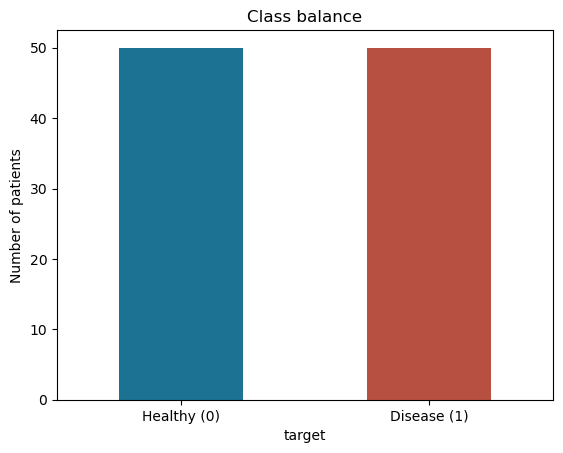

In [3]:
# Quick inspection: how many healthy vs disease patients do we have?
print(metadata["target"].value_counts())

# Basic stats on age
print("\nAge stats:")
print(metadata["age"].describe())

# Class balance plot
metadata["target"].value_counts().plot(kind="bar", color=["#1C7293", "#B85042"])
plt.xticks([0, 1], ["Healthy (0)", "Disease (1)"], rotation=0)
plt.ylabel("Number of patients")
plt.title("Class balance")
plt.show()

## Step 2: Image Processing — "How does an image become numbers?"

A digital image is **already** a grid of numbers — that's the key idea!

- A grayscale image is a 2D grid of pixels, each pixel is a brightness
  value from 0 (black) to 255 (white).
- A color (RGB) image is a **3D array**: height × width × 3 channels
  (Red, Green, Blue). Each channel is a 2D grid of numbers 0–255.

So "loading an image" really means: **load a big array of integers.**

To use images in ML we typically:
1. **Open** the image file
2. **Resize** it so every image has the same shape (models need fixed-size input)
3. **Normalize** pixel values (scale 0–255 down to 0–1, which helps models train)
4. **Convert to a NumPy array** — this array *is* the numeric representation of the image


In [4]:
def load_and_process_image(path, size=(32, 32)):
    """
    Open an image, resize it, normalize pixel values to [0, 1],
    and return it as a NumPy array of shape (size[0], size[1], 3).
    """
    img = Image.open(path).convert("RGB")     # 1. open, force 3 color channels
    img = img.resize(size)                     # 2. resize -> same shape for every patient
    img_array = np.array(img).astype("float32")  # convert pixels to numbers (0-255)
    img_array = img_array / 255.0               # 3. normalize -> range becomes 0.0-1.0
    return img_array                             # 4. this IS the numeric image

# Try it on one patient
example_path = os.path.join(DATASET_DIR, metadata.loc[0, "image"])
example_img_array = load_and_process_image(example_path)

print("Image array shape:", example_img_array.shape)   # (32, 32, 3)
print("Pixel value range:", example_img_array.min(), "to", example_img_array.max())
print()
print("This is a small slice of the numeric array (top-left 3x3 pixels, all 3 color channels):")
print(example_img_array[:3, :3, :])

Image array shape: (32, 32, 3)
Pixel value range: 0.19215687 to 0.9882353

This is a small slice of the numeric array (top-left 3x3 pixels, all 3 color channels):
[[[0.34509805 0.34509805 0.34509805]
  [0.33333334 0.33333334 0.33333334]
  [0.34901962 0.34901962 0.34901962]]

 [[0.34117648 0.34117648 0.34117648]
  [0.3529412  0.3529412  0.3529412 ]
  [0.36862746 0.36862746 0.36862746]]

 [[0.3529412  0.3529412  0.3529412 ]
  [0.3529412  0.3529412  0.3529412 ]
  [0.3529412  0.3529412  0.3529412 ]]]


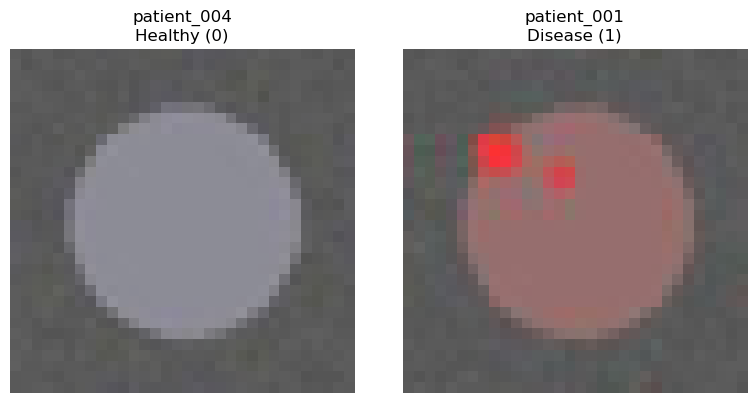

In [5]:
# Visualize a healthy patient's image vs a disease patient's image
healthy_row = metadata[metadata["target"] == 0].iloc[0]
disease_row = metadata[metadata["target"] == 1].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, row, label in zip(axes, [healthy_row, disease_row], ["Healthy (0)", "Disease (1)"]):
    img_arr = load_and_process_image(os.path.join(DATASET_DIR, row["image"]))
    ax.imshow(img_arr)   # matplotlib can display a normalized 0-1 RGB array directly
    ax.set_title(f"{row['patient_id']}\n{label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Notice: disease images tend to have small bright red "spots" (synthetic lesions)
# while healthy images are more uniform. A model can learn to detect this pattern.

## Step 3: Signal Processing — "How does a signal become a vector?"

A time-series signal (like a heartbeat trace) is a list of `(time, value)`
pairs. If every patient's signal has the **same number of time points**
(here: 100), then the signal is *already* a numeric vector of length 100 —
we can feed the `value` column directly as a feature vector.

Steps:
1. **Load** the CSV with pandas → gives us a table of time & value
2. **Extract** the `value` column → a 1D NumPy array (our raw vector)
3. (Optional but common) **Summarize** the signal with statistics
   (mean, std, min, max, etc.) — this turns a long vector into a handful
   of descriptive numbers, similar to what we did for EMG features.


In [6]:
def load_signal(path):
    """Load a signal CSV and return the raw values as a 1D NumPy array."""
    df = pd.read_csv(path)
    return df["time"].values, df["value"].values

# Try it on the same two example patients
healthy_t, healthy_v = load_signal(os.path.join(DATASET_DIR, healthy_row["signal"]))
disease_t, disease_v = load_signal(os.path.join(DATASET_DIR, disease_row["signal"]))

print("Signal length (number of time points):", len(healthy_v))
print("First 10 raw values (healthy):", np.round(healthy_v[:10], 3))

Signal length (number of time points): 100
First 10 raw values (healthy): [0.49  0.774 0.986 0.998 0.855 0.611 0.331 0.106 0.017 0.048]


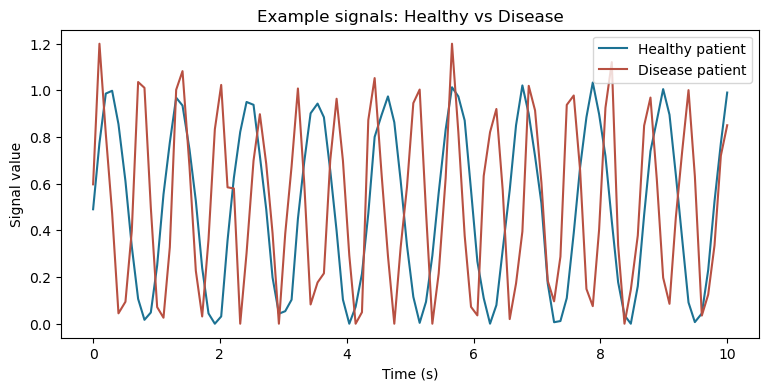

In [7]:
# Plot both signals to see the difference visually
plt.figure(figsize=(9, 4))
plt.plot(healthy_t, healthy_v, label="Healthy patient", color="#1C7293")
plt.plot(disease_t, disease_v, label="Disease patient", color="#B85042")
plt.xlabel("Time (s)")
plt.ylabel("Signal value")
plt.title("Example signals: Healthy vs Disease")
plt.legend()
plt.show()

# Notice: the disease signal is faster (higher frequency), noisier,
# and has occasional sharp spikes -- an ML model can learn these patterns.

In [8]:
def signal_to_features(values):
    """
    Turn a raw signal vector into a small set of descriptive numeric
    features (this is the SAME idea as the EMG feature extraction from
    the earlier project, just simplified).
    """
    return np.array([
        values.mean(),
        values.std(),
        values.min(),
        values.max(),
        np.ptp(values),          # peak-to-peak range (max - min)
        np.mean(np.abs(np.diff(values))),  # average change between consecutive points
    ])

example_features = signal_to_features(healthy_v)
print("Signal summary features (6 numbers):", np.round(example_features, 4))
print("Feature names: mean, std, min, max, range, avg_change")

Signal summary features (6 numbers): [0.4989 0.3493 0.     1.0338 1.0338 0.1835]
Feature names: mean, std, min, max, range, avg_change


## Step 4: Text Processing — "How does text become numbers?"

Computers can't understand words directly. **TF-IDF** (Term
Frequency–Inverse Document Frequency) is one of the simplest and most
classic ways to turn text into numbers:

- **Term Frequency (TF)**: how often a word appears in *this* sentence.
- **Inverse Document Frequency (IDF)**: words that appear in *almost every*
  sentence (like "patient", "the") get a **low** weight, because they
  don't help distinguish between classes. Rare, specific words (like
  "dizzy" or "palpitations") get a **higher** weight.
- TF-IDF score = TF × IDF. The result: every sentence becomes a vector of
  numbers, one number per word in the vocabulary, where more
  "informative" words get bigger values.

We are **not** using BERT or word embeddings here — TF-IDF is simpler,
fully interpretable, and a great starting point before moving to more
advanced NLP.


In [9]:
# Fit TF-IDF on all patient text notes
tfidf = TfidfVectorizer(max_features=30, stop_words="english")
text_features_all = tfidf.fit_transform(metadata["text"]).toarray()

print("TF-IDF feature matrix shape:", text_features_all.shape)   # (100 patients, up to 30 words)
print("\nVocabulary learned (the numeric columns correspond to these words):")
print(tfidf.get_feature_names_out())

TF-IDF feature matrix shape: (100, 30)

Vocabulary learned (the numeric columns correspond to these words):
['appears' 'breath' 'checkup' 'chest' 'complains' 'complaints' 'concerns'
 'discomfort' 'dizzy' 'energy' 'fatigue' 'feels' 'healthy' 'heartbeat'
 'irregular' 'levels' 'mild' 'normal' 'pain' 'patient' 'persistent'
 'raised' 'reports' 'routine' 'shortness' 'sleeping' 'symptoms'
 'tightness' 'tiredness' 'weak']


In [10]:
# Inspect one example sentence and its numeric representation
example_text = metadata.loc[0, "text"]
example_vec = tfidf.transform([example_text]).toarray()[0]

print("Original text:", example_text)
print("\nNon-zero TF-IDF values for this sentence:")
for word, score in zip(tfidf.get_feature_names_out(), example_vec):
    if score > 0:
        print(f"  {word:15s} -> {score:.3f}")

Original text: Experiencing fatigue and mild chest pain

Non-zero TF-IDF values for this sentence:
  chest           -> 0.389
  fatigue         -> 0.584
  mild            -> 0.555
  pain            -> 0.447


## Recap: Numbers → Features

At this point every modality has become a numeric vector per patient:

| Modality | Raw form | Numeric form |
|---|---|---|
| Image | JPG file | 32×32×3 array → flattened to a feature vector |
| Signal | CSV file | 100 raw values → 6 summary features |
| Text | Sentence | TF-IDF vector (≈30 numbers) |

Next, we'll build **one simple model per modality** to see how well each
modality *alone* can predict Healthy vs Disease.


## Step 5: Build Three Simple Models (one per modality)

For a fair comparison, we first build all our numeric features for the
**entire dataset** (all 100 patients), then split into train/test sets,
then train one simple model per modality:

- **Image → simple neural network** (`MLPClassifier` on flattened pixels — a "CNN-lite")
- **Signal → simple neural network** (`MLPClassifier` on the 6 summary features)
- **Text → Logistic Regression** (a classic, simple linear classifier on TF-IDF features)

We deliberately start with *simple* models. Later, you can swap:
- the image `MLPClassifier` → a real CNN
- the signal `MLPClassifier` → an LSTM
- the text `TfidfVectorizer` + `LogisticRegression` → BERT embeddings

...without changing the rest of the pipeline.


In [11]:
# --- Build features for ALL patients at once ---

image_feature_list = []
signal_feature_list = []
signal_raw_list = []

for _, row in metadata.iterrows():
    # Image -> flattened normalized pixel array
    img_arr = load_and_process_image(os.path.join(DATASET_DIR, row["image"]))
    image_feature_list.append(img_arr.flatten())   # (32*32*3,) = 3072 numbers

    # Signal -> 6 summary features
    _, values = load_signal(os.path.join(DATASET_DIR, row["signal"]))
    signal_feature_list.append(signal_to_features(values))

X_image = np.array(image_feature_list)     # shape: (100, 3072)
X_signal = np.array(signal_feature_list)   # shape: (100, 6)
X_text = tfidf.transform(metadata["text"]).toarray()   # shape: (100, ~30)
y = metadata["target"].values              # shape: (100,)

print("X_image shape :", X_image.shape)
print("X_signal shape:", X_signal.shape)
print("X_text shape  :", X_text.shape)
print("y shape       :", y.shape)

X_image shape : (100, 3072)
X_signal shape: (100, 6)
X_text shape  : (100, 30)
y shape       : (100,)


In [12]:
# --- Train / test split (SAME split reused for every model, for a fair comparison) ---
# We split by row INDEX so image, signal, and text stay aligned to the same patients.

indices = np.arange(len(metadata))
idx_train, idx_test, y_train, y_test = train_test_split(
    indices, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Train patients: {len(idx_train)}  |  Test patients: {len(idx_test)}")

Train patients: 75  |  Test patients: 25


In [13]:
def evaluate_model(name, y_true, y_pred):
    """Print accuracy/precision/recall/F1 and show a confusion matrix."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{name}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall   : {rec:.3f}")
    print(f"  F1-score : {f1:.3f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Disease"])
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

results = []  # we will collect every model's scores here for Step 7

Image Only
  Accuracy : 1.000
  Precision: 1.000
  Recall   : 1.000
  F1-score : 1.000


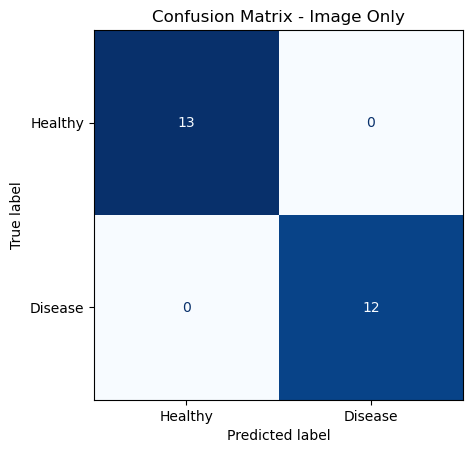

In [14]:
# ---------- 5a. IMAGE-ONLY MODEL ----------
# A simple feed-forward neural network (MLP) on the flattened pixel values.
# This is the "before CNN" version: no convolution, just raw pixels -> dense layers.

scaler_img = StandardScaler()
X_image_train = scaler_img.fit_transform(X_image[idx_train])
X_image_test = scaler_img.transform(X_image[idx_test])

model_image = MLPClassifier(hidden_layer_sizes=(64, 16), max_iter=1000, random_state=RANDOM_STATE)
model_image.fit(X_image_train, y_train)
pred_image = model_image.predict(X_image_test)

results.append(evaluate_model("Image Only", y_test, pred_image))

Signal Only
  Accuracy : 1.000
  Precision: 1.000
  Recall   : 1.000
  F1-score : 1.000


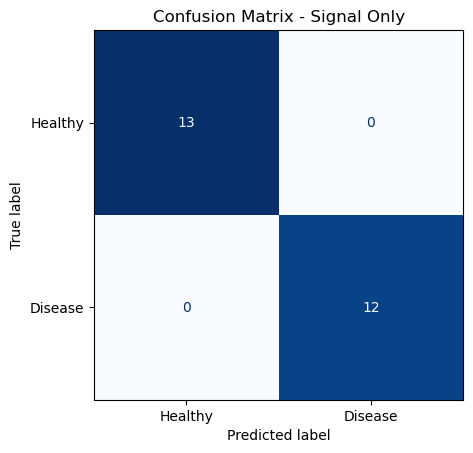

In [15]:
# ---------- 5b. SIGNAL-ONLY MODEL ----------
# Simple neural network on the 6 summary features of each signal.

scaler_sig = StandardScaler()
X_signal_train = scaler_sig.fit_transform(X_signal[idx_train])
X_signal_test = scaler_sig.transform(X_signal[idx_test])

model_signal = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=RANDOM_STATE)
model_signal.fit(X_signal_train, y_train)
pred_signal = model_signal.predict(X_signal_test)

results.append(evaluate_model("Signal Only", y_test, pred_signal))

Text Only
  Accuracy : 0.960
  Precision: 1.000
  Recall   : 0.917
  F1-score : 0.957


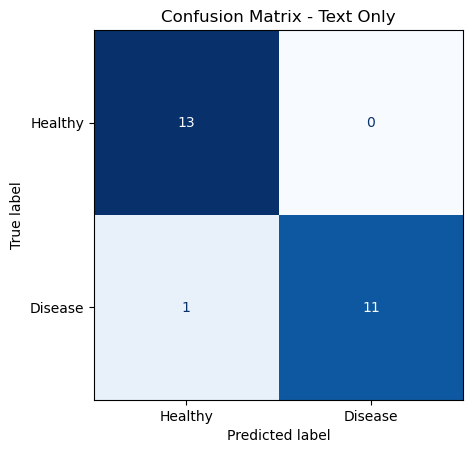

In [16]:
# ---------- 5c. TEXT-ONLY MODEL ----------
# Logistic Regression on TF-IDF features -- a simple, classic linear text classifier.

X_text_train = X_text[idx_train]
X_text_test = X_text[idx_test]

model_text = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_text.fit(X_text_train, y_train)
pred_text = model_text.predict(X_text_test)

results.append(evaluate_model("Text Only", y_test, pred_text))

## Step 6: Simple Multimodal Fusion

Now that we understand each modality separately, let's **combine** them.

The simplest possible fusion strategy is **early fusion by concatenation**:
just glue the feature vectors of all modalities together into one long
vector per patient, then train a single classifier on that combined vector.

```
image_features  (3072 numbers)  ┐
signal_features (6 numbers)     ├──► combined_features (one long vector) ──► classifier ──► prediction
text_features   (~30 numbers)   ┘
```

This is called **early fusion** because we merge the modalities *before*
the model sees them, as opposed to *late fusion* (train 3 separate models
and combine their predictions/probabilities at the end).


In [17]:
def build_combined_features(modalities_scaled):
    """Simply concatenate a list of already-scaled feature matrices along axis=1 (columns)."""
    return np.concatenate(modalities_scaled, axis=1)

# Example: combine ALL three modalities (Image + Signal + Text)
X_combined_train = build_combined_features([X_image_train, X_signal_train, X_text_train])
X_combined_test = build_combined_features([X_image_test, X_signal_test, X_text_test])

print("Combined feature vector length per patient:", X_combined_train.shape[1],
      "=", X_image_train.shape[1], "(image) +", X_signal_train.shape[1],
      "(signal) +", X_text_train.shape[1], "(text)")

Combined feature vector length per patient: 3108 = 3072 (image) + 6 (signal) + 30 (text)


Image + Signal + Text (Fusion)
  Accuracy : 1.000
  Precision: 1.000
  Recall   : 1.000
  F1-score : 1.000


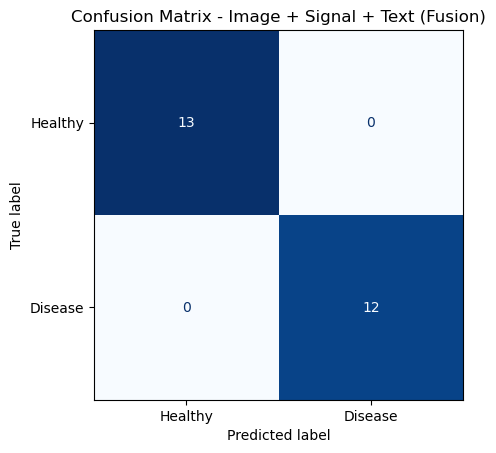

In [18]:
# Train one simple neural network classifier on the FULLY combined features
model_fusion_all = MLPClassifier(hidden_layer_sizes=(64, 16), max_iter=1000, random_state=RANDOM_STATE)
model_fusion_all.fit(X_combined_train, y_train)
pred_fusion_all = model_fusion_all.predict(X_combined_test)

results.append(evaluate_model("Image + Signal + Text (Fusion)", y_test, pred_fusion_all))

## Step 7: Final Comparison

Let's now train the **remaining modality combinations** so we can compare
every possible pairing, plus all three individually and together.
This helps answer: *does adding more modalities actually help?*


In [19]:
def train_and_score(name, feature_list_train, feature_list_test):
    """Helper: concatenate given (already scaled) feature sets, train an MLP, evaluate."""
    X_train_combo = build_combined_features(feature_list_train)
    X_test_combo = build_combined_features(feature_list_test)

    model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_train_combo, y_train)
    pred = model.predict(X_test_combo)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

# Image + Signal
results.append(train_and_score("Image + Signal",
                                [X_image_train, X_signal_train],
                                [X_image_test, X_signal_test]))

# Image + Text
results.append(train_and_score("Image + Text",
                                [X_image_train, X_text_train],
                                [X_image_test, X_text_test]))

# Signal + Text
results.append(train_and_score("Signal + Text",
                                [X_signal_train, X_text_train],
                                [X_signal_test, X_text_test]))

print("All combinations trained.")

All combinations trained.


In [20]:
# ---------- Final comparison table ----------
results_df = pd.DataFrame(results)

# Keep a nice, readable order: single modalities -> pairs -> all three
order = ["Image Only", "Signal Only", "Text Only",
         "Image + Signal", "Image + Text", "Signal + Text",
         "Image + Signal + Text (Fusion)"]
results_df["Model"] = pd.Categorical(results_df["Model"], categories=order, ordered=True)
results_df = results_df.sort_values("Model").reset_index(drop=True)

results_df_display = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
    results_df_display[col] = results_df_display[col].round(3)

results_df_display

,Model,Accuracy,Precision,Recall,F1-score
0,Image Only,1.00,1.0,1.000,1.000
1,Signal Only,1.00,1.0,1.000,1.000
2,Text Only,0.96,1.0,0.917,0.957
3,Image + Signal,1.00,1.0,1.000,1.000
4,Image + Text,1.00,1.0,1.000,1.000
5,Signal + Text,1.00,1.0,1.000,1.000
6,Image + Signal + Text (Fusion),1.00,1.0,1.000,1.000


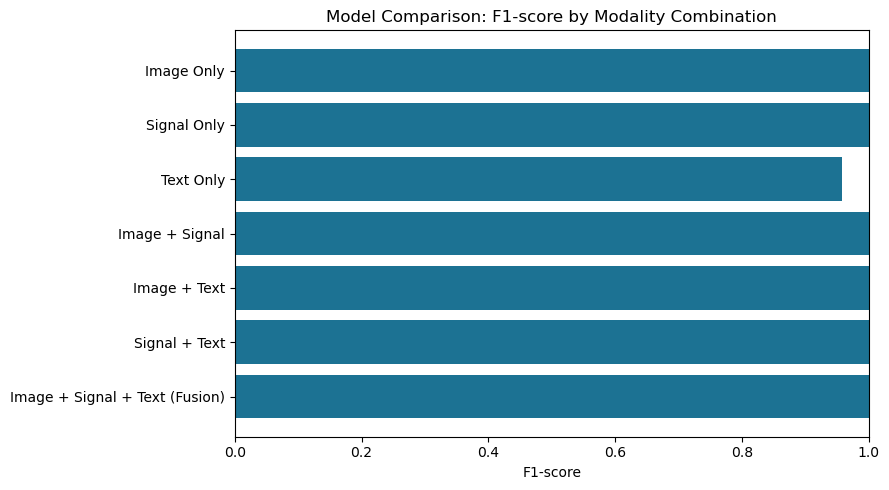

In [21]:
# Visual comparison of F1-scores across all combinations
plt.figure(figsize=(9, 5))
plt.barh(results_df_display["Model"], results_df_display["F1-score"], color="#1C7293")
plt.xlabel("F1-score")
plt.title("Model Comparison: F1-score by Modality Combination")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary — What You Just Learned

1. **Image → Numbers**: a picture is a grid of pixel values; we resized
   and normalized it into a fixed-size NumPy array.
2. **Signal → Numbers**: a time-series is already a list of numbers; we
   either used the raw values or summarized them into a few descriptive
   statistics.
3. **Text → Numbers**: TF-IDF turns each sentence into a vector where
   informative words get higher weight.
4. **Numbers → Features**: each modality became a fixed-length numeric
   feature vector per patient.
5. **Features → Fusion**: we concatenated the feature vectors from
   different modalities into one combined vector (early fusion).
6. **Fusion → Prediction**: a single classifier (or several, for
   comparison) was trained on the combined features to predict
   Healthy vs Disease.

### Where to go next
Now that you understand the full pipeline with SIMPLE models, you can
upgrade each piece independently, without changing the overall structure:

- Replace the image `MLPClassifier` on flattened pixels with a real **CNN**
  (e.g. a small `Conv2D` network in PyTorch/Keras).
- Replace the signal summary-feature `MLPClassifier` with an **LSTM** or
  1D-CNN that reads the raw sequence directly.
- Replace `TfidfVectorizer` + `LogisticRegression` with **BERT** sentence
  embeddings.
- Replace simple concatenation fusion with **attention-based fusion** or
  a learned gating mechanism.

The key insight to carry forward: **multimodal ML is just "turn everything
into numbers, then combine the numbers."** Everything else is refinement.
